<a href="https://colab.research.google.com/github/joseph2022/Disease-Prediction/blob/main/Heart_DIsease2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction Attempt 2- Claysy

In [226]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, roc_auc_score,roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping



In [227]:
data=pd.read_csv('/content/drive/MyDrive/Disease_Prediction/heart.csv')
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [228]:
data.shape

(1025, 14)

In [229]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [230]:
data.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [231]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [232]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [233]:
data['target'].value_counts()

,count
target,
1,526
0,499


In [234]:
# checking duplicates
duplicates=data.duplicated().sum()
print("Duplicate Rows:",duplicates)

if duplicates>0:
  data=data.drop_duplicates()
  print("Duplicates Removed")

# class distribution
print("\nClass Distribution:")
print(data['target'].value_counts())


Duplicate Rows: 723
Duplicates Removed

Class Distribution:
target
1    164
0    138
Name: count, dtype: int64


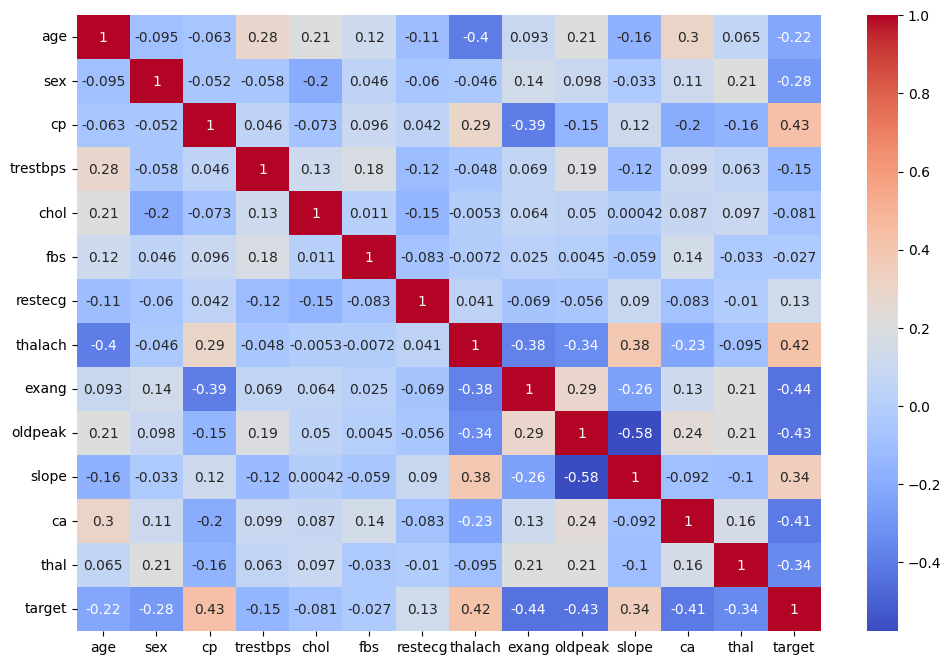

In [235]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.show()

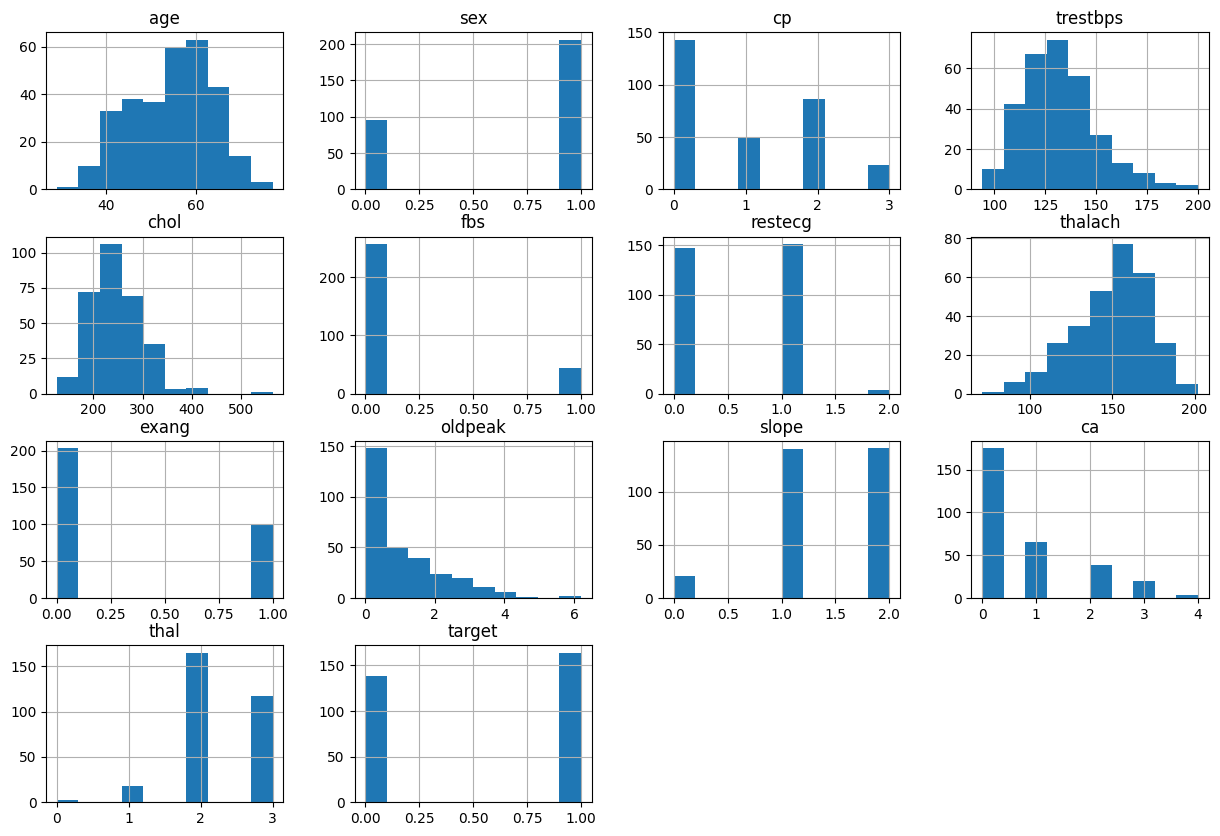

In [236]:
data.hist(figsize=(15,10))
plt.show()

In [237]:
# droping the target variable
x=data.drop('target',axis=1)
y=data.target

In [238]:
# Train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42,stratify=y)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(241, 13)
(61, 13)
(241,)
(61,)


In [239]:
# Scaling - scales the data so all features are kept in the same range
scaler=StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [240]:
# Applying Logistic Regression
print('\n===== LOGISTIC REGRESSION =====')
lr= LogisticRegression()
lr.fit(x_train_scaled,y_train)

y_pred_lr=lr.predict(x_test_scaled)
y_pred_lr
y_prob_lr= lr.predict_proba(x_test_scaled)[:,1]

lr_accuracy= accuracy_score(y_test,y_pred_lr)
lr_roc=roc_auc_score(y_test,y_prob_lr)

print('Accuracy:',round(lr_accuracy,4))
print('ROC-AUC:',round(lr_roc,4))

print(classification_report (y_test,y_pred_lr))


===== LOGISTIC REGRESSION =====
Accuracy: 0.8033
ROC-AUC: 0.8712
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



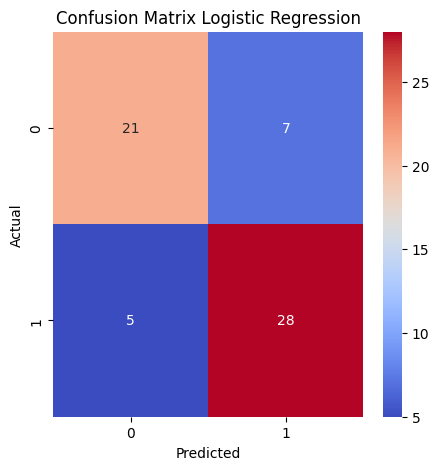

In [241]:
cm=confusion_matrix(y_test,y_pred_lr)
cm
plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Logistic Regression")
plt.show()

In [242]:
print("\n===== RANDOM FOREST =====")

rf=RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(x_train_scaled,y_train)

y_pred_rf=rf.predict(x_test_scaled)
y_pred_rf
y_prob_rf= rf.predict_proba(x_test_scaled)[:,1]

rf_accuracy= accuracy_score(y_test,y_pred_rf)
rf_roc= roc_auc_score(y_test,y_prob_rf)

print("Accuracy:",round(rf_accuracy,4))
print("ROC-AUC:",round(rf_roc,4))

print(classification_report(y_test, y_pred_rf))


===== RANDOM FOREST =====
Accuracy: 0.7541
ROC-AUC: 0.868
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



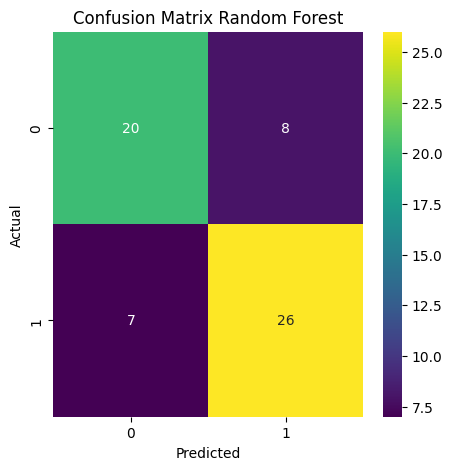

In [243]:
cm=confusion_matrix(y_test,y_pred_rf)
cm
plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True, fmt='d',cmap='viridis')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Random Forest")
plt.show()

In [244]:
print("\n===== SVM =====")

svm= SVC(probability=True)
svm.fit(x_train_scaled,y_train)

y_pred_svm= svm.predict(x_test_scaled)
y_pred_svm
y_prob_svm= svm.predict_proba(x_test_scaled)[:,1]

svm_accuracy = accuracy_score(y_test,y_pred_svm)
svm_roc = roc_auc_score(y_test,y_prob_svm)

print("Accuracy:",round(svm_accuracy,4))
print("ROC-AUC:",round(svm_roc,4))

print(classification_report(y_test,y_pred_svm))



===== SVM =====
Accuracy: 0.7705
ROC-AUC: 0.842
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        28
           1       0.77      0.82      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



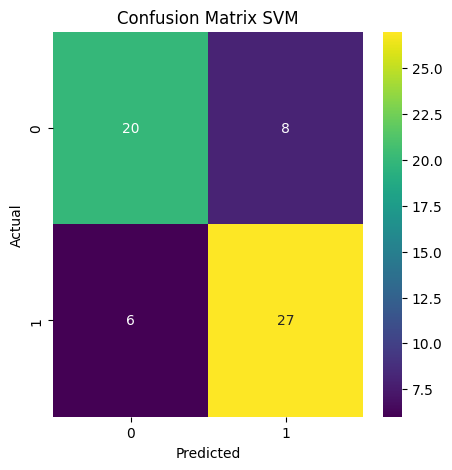

In [245]:
cm=confusion_matrix(y_test,y_pred_svm)
cm
plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True, fmt='d',cmap='viridis')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix SVM")
plt.show()

In [252]:
# ANN using tensorflow

nn_model= keras.Sequential([
    keras.Input(shape=(x_train_scaled.shape[1],)),
    layers.Dense(32,activation='relu'),
    layers.Dense(16,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

nn_model.compile(
    optimizer='adam',loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss',patience=5)

history= nn_model.fit(
    x_train_scaled,y_train,epochs=150,
    batch_size=16,
    validation_data=(x_test_scaled,y_test),
    callbacks=[early_stop],
    verbose=0
)


In [253]:
# Evaluation
loss,nn_accuracy = nn_model.evaluate(x_test_scaled,y_test,verbose=0)

y_prob_nn= nn_model.predict(x_test_scaled,verbose=0)
nn_roc=roc_auc_score(y_test,y_prob_nn)

print("Accuracy:",round(nn_accuracy,4))
print("ROC-AUC:",round(nn_roc,4))

Accuracy: 0.7869
ROC-AUC: 0.8496


In [255]:
# Comparing all models and checking for the best

comparison=pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","SVM","ANN"],
    "Accuracy": [lr_accuracy,rf_accuracy,svm_accuracy,nn_accuracy],
    "ROC-AUC": [lr_roc,rf_roc,svm_roc,nn_roc]
})
print("Model Comparison")
print(comparison.sort_values(by="ROC-AUC",ascending=False))

Model Comparison
                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.803279  0.871212
1        Random Forest  0.754098  0.867965
3                  ANN  0.786885  0.849567
2                  SVM  0.770492  0.841991


In [256]:
best_model_name=comparison.sort_values(
    by="ROC-AUC", ascending=False).iloc[0]["Model"]
print('Best Model:',best_model_name)

if best_model_name=="Logistic Regression":
  best_model=lr
elif best_model_name=="Random Forest":
  best_model=rf
elif best_model_name=="SVM":
  best_model=svm
else:
  best_model=nn_model

Best Model: Logistic Regression
